In [4]:
import pandas as pd
from Lectura.API.Api import get_df_unificado
from Procesamiento.Separacion import Separacion
from Procesamiento.AtributosSelect import ejecutar_interactivo
from Procesamiento.plot_dataframe import plot_df
from Lectura.ArchivoPlano.APlano import load_to_dataframe
from Procesamiento.ObtenerColumnas import obtener_columnas_archivo

In [5]:
# Solicitar dataset_id al usuario
dataset_id = "055A4D"
print('Etapa1')
resultado = get_df_unificado(
    dataset_id=dataset_id,
    fecha_inicio="2025-01-01",
    fecha_final="2025-02-01",
    url_template_namecols="https://www.simem.co/backend-files/api/detalle-datos-publicos?datasetId={dataset_id}",
    nombre_csv=f"data_{dataset_id}.csv"
)


Etapa1
****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Generación real"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0075528621673583984
Extraccion de registros: 129.57907605171204
End of data extracting process
****************************************************************************************************
CSV guardado en: d:\ambiente\escritorio\PPracticas\Almacenamiento\data_055A4D.csv


In [6]:
print('Etapa2')
df = resultado["dataframe"]
columnas = resultado["namecolumns"]

Etapa2


In [7]:
print('Etapa2')
df_filtro = ejecutar_interactivo(df)


Etapa2
=== Exportar CSV por un valor específico de una columna ===
Generando archivos temporales (no se usa carpeta fija)

Columnas disponibles:
  1. CodigoVariable
  2. FechaHora
  3. CodigoDuracion
  4. UnidadMedida
  5. CodigoSICAgente
  6. CodigoPlanta
  7. Version
  8. Valor

Trabajando con la columna: CodigoSICAgente

Resumen de la columna seleccionada:
  - Valores con nombre (no vacíos): 90
  - Filas NaN (vacías): 0

Valores disponibles (en orden de aparición):
  1. ISGG  →  119880 filas
  2. NTCG  →  39960 filas
  3. EMEG  →  12696 filas
  4. EPSG  →  278856 filas
  5. GNYG  →  35520 filas
  6. EPMG  →  195360 filas
  7. GPEG  →  22200 filas
  8. HDTG  →  26640 filas
  9. ENDG  →  119880 filas
  10. ELIG  →  2376 filas
  11. ERRG  →  54144 filas
  12. RTAG  →  4440 filas
  13. TERG  →  8880 filas
  14. UNGG  →  54504 filas
  15. DRUG  →  4440 filas
  16. GPYG  →  8880 filas
  17. TMVG  →  4440 filas
  18. SDCG  →  4440 filas
  19. AAGG  →  22200 filas
  20. EYCG  →  7752 filas


In [9]:
print('Etapa3.1')
df_filtro = ejecutar_interactivo(df_filtro)

Etapa3.1
=== Exportar CSV por un valor específico de una columna ===
Generando archivos temporales (no se usa carpeta fija)

Columnas disponibles:
  1. CodigoVariable
  2. FechaHora
  3. CodigoDuracion
  4. UnidadMedida
  5. CodigoSICAgente
  6. CodigoPlanta
  7. Version
  8. Valor

Trabajando con la columna: Version

Resumen de la columna seleccionada:
  - Valores con nombre (no vacíos): 6
  - Filas NaN (vacías): 0

Valores disponibles (en orden de aparición):
  1. TX2  →  744 filas
  2. TXR  →  768 filas
  3. TX1  →  624 filas
  4. TX4  →  768 filas
  5. TX3  →  768 filas
  6. TXF  →  768 filas

[OK] Se generó 1 archivo(s).
[OK] Filas exportadas: 744
  - Version_TX2_bnecqygl.csv → 744 filas


In [10]:
df_filtro.head()

,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,CodigoSICAgente,CodigoPlanta,Version,Valor
0,GReal,2025-01-31 03:00:00,PT1H,kWh,ISGG,SOG1,TX2,473704.40
1,GReal,2025-01-31 02:00:00,PT1H,kWh,ISGG,SOG1,TX2,464174.10
2,GReal,2025-01-31 01:00:00,PT1H,kWh,ISGG,SOG1,TX2,438214.33
3,GReal,2025-01-31 00:00:00,PT1H,kWh,ISGG,SOG1,TX2,382440.09
65,GReal,2025-01-31 23:00:00,PT1H,kWh,ISGG,SOG1,TX2,380073.26


In [11]:
print("Etapa4")
print(columnas)

df_general , meta = Separacion(columnas, df_filtro)
df_general.head(100)

Etapa4
['CodigoVariable', 'Valor', 'CodigoPlanta', 'UnidadMedida', 'CodigoSICAgente', 'Version', 'FechaHora', 'CodigoDuracion']


,FechaHora,Valor
0,2025-01-31 03:00:00,473704.40
1,2025-01-31 02:00:00,464174.10
2,2025-01-31 01:00:00,438214.33
3,2025-01-31 00:00:00,382440.09
65,2025-01-31 23:00:00,380073.26
...,...,...
164529,2025-01-28 23:00:00,548827.62
263346,2025-01-27 00:00:00,609319.07
263347,2025-01-27 01:00:00,588850.77
263348,2025-01-27 02:00:00,536085.73


In [12]:
# Cambia la parte donde se asignan las columnas en df_general
df_general.iloc[:, 0] = pd.to_datetime(df_general.iloc[:, 0])  # Convertir la primera columna a fecha
df_general = df_general.sort_values(by=df_general.columns[0])  # Ordenar por la primera columna
df_general.iloc[:, 1] = df_general.iloc[:, 1] # Multiplicar la segunda columna por 1 millón


In [13]:
df_general.head()

,FechaHora,Valor
1550417,2025-01-01 00:00:00,819889.61
1550416,2025-01-01 01:00:00,819958.13
1550415,2025-01-01 02:00:00,795818.74
1550414,2025-01-01 03:00:00,819271.57
1550413,2025-01-01 04:00:00,819857.48


In [14]:
# -*- coding: utf-8 -*-
"""
Graficador de series temporales con múltiples vistas
- Primera columna: fechas/tiempos
- Segunda columna: valores numéricos
Crea: línea, barras, área, dispersión, boxplot por mes y heatmap temporal.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Parámetros de entrada
# =========================
# Opción A: leer desde CSV (descomenta y pone tu ruta)
CSV_PATH = None  # p.ej.: r"datos/serie.csv"

# Opción B: si ya tienes un DataFrame en memoria llamado `df`,
# deja CSV_PATH=None y el script usará `df` directamente.
# Se espera que df tenga dos columnas: [fecha, valor]

# =========================
# Funciones utilitarias
# =========================

def cargar_datos(csv_path=None, df=None):
    """
    Carga datos ya sea desde CSV o usa un DataFrame dado.
    Asume: 1ra columna = fecha/tiempo, 2da columna = valor.
    """
    if csv_path is not None:
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"No se encontró el archivo: {csv_path}")
        tmp = pd.read_csv(csv_path)
    else:
        if df is None:
            raise ValueError("Proporciona CSV_PATH o un DataFrame `df` con dos columnas.")
        tmp = df.copy()

    if tmp.shape[1] < 2:
        raise ValueError("Se requieren al menos 2 columnas: tiempo y valor.")

    # Renombrar de forma estándar
    tmp = tmp.iloc[:, :2].copy()
    tmp.columns = ["fecha", "valor"]

    # Parse de fechas
    tmp["fecha"] = pd.to_datetime(tmp["fecha"], errors="coerce")
    # Limpiar filas con fecha no válida
    tmp = tmp.dropna(subset=["fecha"])
    # Convertir valor a numérico
    tmp["valor"] = pd.to_numeric(tmp["valor"], errors="coerce")
    tmp = tmp.dropna(subset=["valor"])

    # Ordenar por tiempo
    tmp = tmp.sort_values("fecha").reset_index(drop=True)

    return tmp


def hay_componente_hora(series_fechas: pd.Series) -> bool:
    """
    Retorna True si hay componente horario (no todos los tiempos están a medianoche).
    """
    # Si la parte de hora/min/seg no es todo cero, asumimos que hay componente horario
    return not ((series_fechas.dt.hour == 0) &
                (series_fechas.dt.minute == 0) &
                (series_fechas.dt.second == 0)).all()


def preparar_dimensiones_temporales(df: pd.DataFrame):
    """
    Agrega columnas auxiliares de tiempo: año, mes, día de semana, hora.
    """
    out = df.copy()
    out["anio"] = out["fecha"].dt.year
    out["mes"] = out["fecha"].dt.month
    out["mes_nombre"] = out["fecha"].dt.month_name(locale="es_ES").str.capitalize() \
                        if hasattr(out["fecha"].dt, "month_name") else out["mes"].astype(str)
    out["dow"] = out["fecha"].dt.dayofweek  # 0=Lunes
    out["dow_nombre"] = out["fecha"].dt.day_name(locale="es_ES").str.capitalize() \
                        if hasattr(out["fecha"].dt, "day_name") else out["dow"].astype(str)
    out["hora"] = out["fecha"].dt.hour
    return out


def plot_todos(df: pd.DataFrame, titulo_base: str = "Serie temporal"):
    """
    Genera todas las gráficas: línea, barras, área, dispersión,
    boxplot por mes, heatmap temporal (dow×hora o año×mes).
    """
    # Configuración general
    sns.set(style="whitegrid")
    plt.rcParams["axes.titlesize"] = 12
    plt.rcParams["axes.labelsize"] = 10

    # -------- 1) LÍNEA --------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df["fecha"], df["valor"], color="#1f77b4", linewidth=1.8)
    ax.set_title(f"{titulo_base} - Línea")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    fig.autofmt_xdate()
    plt.tight_layout()

    # -------- 2) BARRAS --------
    # Útil cuando la frecuencia es discreta (mes, día, etc.)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(df["fecha"], df["valor"], color="#2ca02c", width=0.8)
    ax.set_title(f"{titulo_base} - Barras")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    fig.autofmt_xdate()
    plt.tight_layout()

    # -------- 3) ÁREA --------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(df["fecha"], df["valor"], step="pre", alpha=0.3, color="#ff7f0e")
    ax.plot(df["fecha"], df["valor"], color="#ff7f0e", linewidth=1.5)
    ax.set_title(f"{titulo_base} - Área")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    fig.autofmt_xdate()
    plt.tight_layout()

    # -------- 4) DISPERSIÓN --------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(df["fecha"], df["valor"], s=20, alpha=0.7, color="#9467bd")
    ax.set_title(f"{titulo_base} - Dispersión")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    fig.autofmt_xdate()
    plt.tight_layout()

    # Preparar columnas temporales
    dft = preparar_dimensiones_temporales(df)

    # -------- 5) BOXPLOT POR MES (agregado por mes) --------
    # Si hay múltiples observaciones por mes, esto muestra distribución.
    fig, ax = plt.subplots(figsize=(10, 4))
    order_meses = [1,2,3,4,5,6,7,8,9,10,11,12]
    sns.boxplot(
        data=dft,
        x="mes",
        y="valor",
        order=order_meses,
        ax=ax,
        color="#8c564b"
    )
    ax.set_title(f"{titulo_base} - Boxplot por mes")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Valor")
    ax.set_xticklabels([ "Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic" ])
    plt.tight_layout()

    # -------- 6) HEATMAP TEMPORAL --------
    # Si hay componente horario, usamos DíaSemana×Hora; si no, Año×Mes.
    if hay_componente_hora(df["fecha"]):
        # Promedio por (día de semana, hora)
        piv = dft.pivot_table(index="dow", columns="hora", values="valor", aggfunc="mean")
        # Reordenar días L->D
        piv = piv.reindex([0,1,2,3,4,5,6])
        fig, ax = plt.subplots(figsize=(12, 4))
        sns.heatmap(piv, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Valor medio"})
        ax.set_title(f"{titulo_base} - Heatmap (Día de semana × Hora)")
        ax.set_xlabel("Hora del día")
        ax.set_ylabel("Día de la semana")
        ax.set_yticklabels(["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"], rotation=0)
        plt.tight_layout()
    else:
        # Promedio por (año, mes)
        piv = dft.pivot_table(index="anio", columns="mes", values="valor", aggfunc="mean")
        # Asegurar 12 columnas (1-12)
        piv = piv.reindex(columns=range(1,13))
        fig, ax = plt.subplots(figsize=(12, 4))
        sns.heatmap(piv, cmap="YlGnBu", ax=ax, cbar_kws={"label": "Valor medio"})
        ax.set_title(f"{titulo_base} - Heatmap (Año × Mes)")
        ax.set_xlabel("Mes")
        ax.set_ylabel("Año")
        ax.set_xticklabels([ "Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic" ], rotation=0)
        plt.tight_layout()

    plt.show()




C:\Users\65698\AppData\Local\Temp\ipykernel_26888\4247275281.py:156: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ "Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic" ])


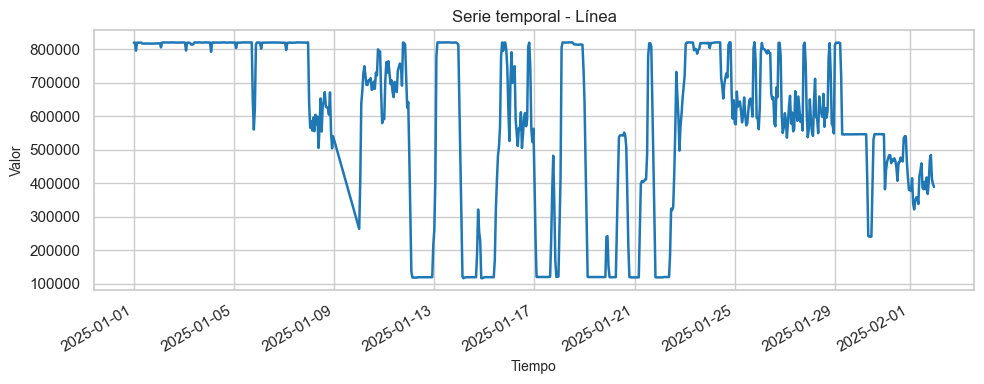

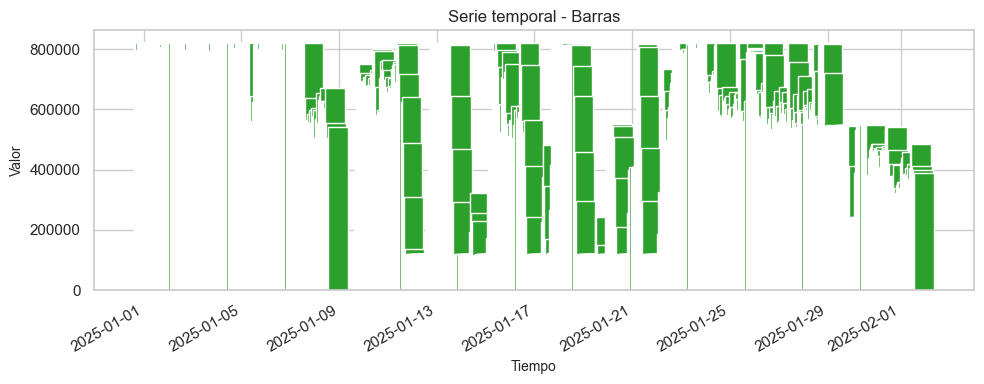

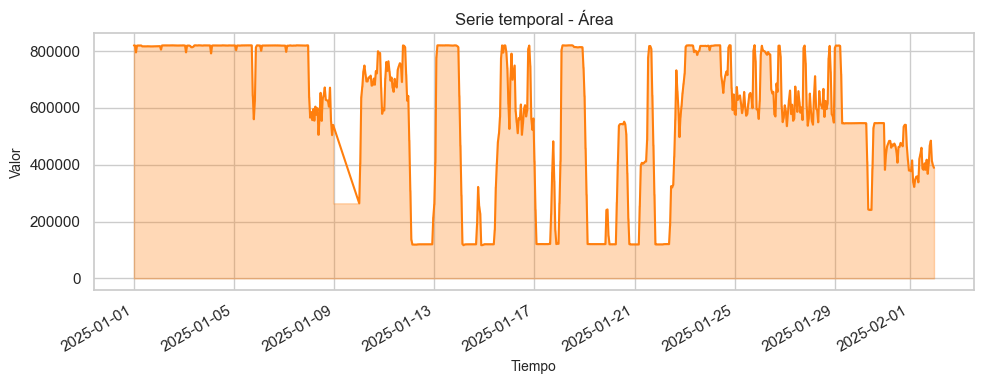

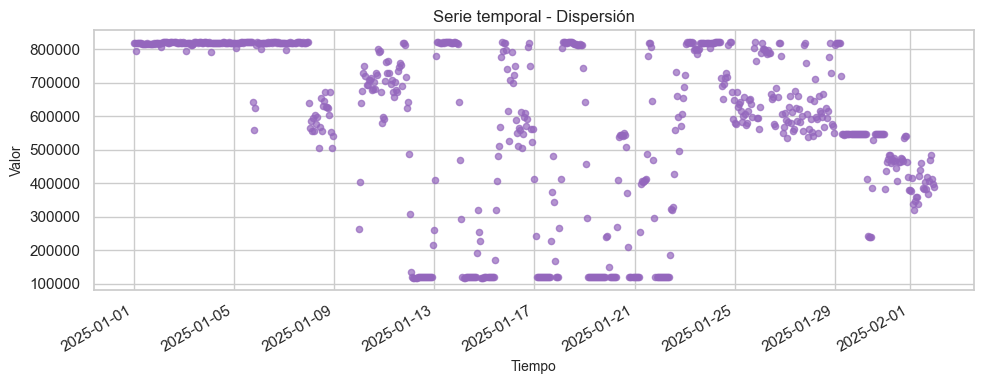

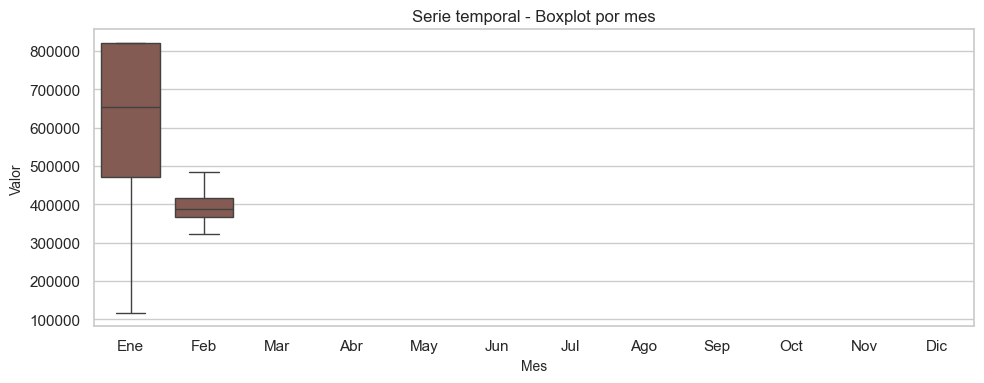

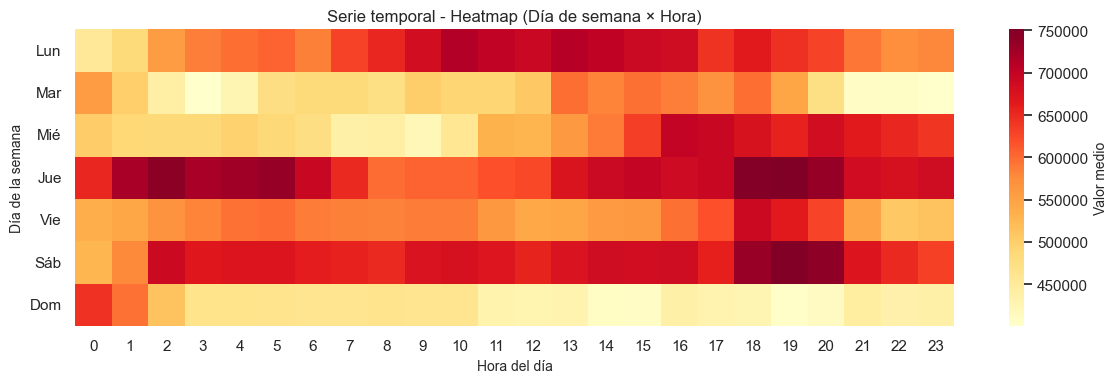

In [16]:
# Normalizar columnas y tipos usando la función definida en la celda del graficador
plot_todos(cargar_datos(df=df_general))

In [ ]:
# -*- coding: utf-8 -*-
"""
Graficador de series temporales con múltiples vistas
- Primera columna: fechas/tiempos
- Segunda columna: valores numéricos
Crea: línea, barras, área, dispersión, boxplot por mes y heatmap temporal.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Parámetros de entrada
# =========================
# Opción A: leer desde CSV (descomenta y pone tu ruta)
CSV_PATH = None  # p.ej.: r"datos/serie.csv"

# Opción B: si ya tienes un DataFrame en memoria llamado `df`,
# deja CSV_PATH=None y el script usará `df` directamente.
# Se espera que df tenga dos columnas: [fecha, valor]

# =========================
# Funciones utilitarias
# =========================

def cargar_datos(csv_path=None, df=None):
    """
    Carga datos ya sea desde CSV o usa un DataFrame dado.
    Asume: 1ra columna = fecha/tiempo, 2da columna = valor.
    """
    if csv_path is not None:
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"No se encontró el archivo: {csv_path}")
        tmp = pd.read_csv(csv_path)
    else:
        if df is None:
            raise ValueError("Proporciona CSV_PATH o un DataFrame `df` con dos columnas.")
        tmp = df.copy()

    if tmp.shape[1] < 2:
        raise ValueError("Se requieren al menos 2 columnas: tiempo y valor.")

    # Renombrar de forma estándar
    tmp = tmp.iloc[:, :2].copy()
    tmp.columns = ["fecha", "valor"]

    # Parse de fechas
    tmp["fecha"] = pd.to_datetime(tmp["fecha"], errors="coerce")
    # Limpiar filas con fecha no válida
    tmp = tmp.dropna(subset=["fecha"])
    # Convertir valor a numérico
    tmp["valor"] = pd.to_numeric(tmp["valor"], errors="coerce")
    tmp = tmp.dropna(subset=["valor"])

    # Ordenar por tiempo
    tmp = tmp.sort_values("fecha").reset_index(drop=True)

    return tmp


def hay_componente_hora(series_fechas: pd.Series) -> bool:
    """
    Retorna True si hay componente horario (no todos los tiempos están a medianoche).
    """
    # Si la parte de hora/min/seg no es todo cero, asumimos que hay componente horario
    return not ((series_fechas.dt.hour == 0) &
                (series_fechas.dt.minute == 0) &
                (series_fechas.dt.second == 0)).all()


def preparar_dimensiones_temporales(df: pd.DataFrame):
    """
    Agrega columnas auxiliares de tiempo: año, mes, día de semana, hora.
    """
    out = df.copy()
    out["anio"] = out["fecha"].dt.year
    out["mes"] = out["fecha"].dt.month
    out["mes_nombre"] = out["fecha"].dt.month_name(locale="es_ES").str.capitalize() \
                        if hasattr(out["fecha"].dt, "month_name") else out["mes"].astype(str)
    out["dow"] = out["fecha"].dt.dayofweek  # 0=Lunes
    out["dow_nombre"] = out["fecha"].dt.day_name(locale="es_ES").str.capitalize() \
                        if hasattr(out["fecha"].dt, "day_name") else out["dow"].astype(str)
    out["hora"] = out["fecha"].dt.hour
    return out


def plot_todos(df: pd.DataFrame, titulo_base: str = "Serie temporal"):
    """
    Genera todas las gráficas: línea, barras, área, dispersión,
    boxplot por mes, heatmap temporal (dow×hora o año×mes).
    """
    # Configuración general
    sns.set(style="whitegrid")
    plt.rcParams["axes.titlesize"] = 12
    plt.rcParams["axes.labelsize"] = 10

    # -------- 1) LÍNEA --------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df["fecha"], df["valor"], color="#1f77b4", linewidth=1.8)
    ax.set_title(f"{titulo_base} - Línea")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    fig.autofmt_xdate()
    plt.tight_layout()

    # -------- 2) BARRAS --------
    # Útil cuando la frecuencia es discreta (mes, día, etc.)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(df["fecha"], df["valor"], color="#2ca02c", width=0.8)
    ax.set_title(f"{titulo_base} - Barras")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    fig.autofmt_xdate()
    plt.tight_layout()

    # -------- 3) ÁREA --------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(df["fecha"], df["valor"], step="pre", alpha=0.3, color="#ff7f0e")
    ax.plot(df["fecha"], df["valor"], color="#ff7f0e", linewidth=1.5)
    ax.set_title(f"{titulo_base} - Área")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    fig.autofmt_xdate()
    plt.tight_layout()

    # -------- 4) DISPERSIÓN --------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(df["fecha"], df["valor"], s=20, alpha=0.7, color="#9467bd")
    ax.set_title(f"{titulo_base} - Dispersión")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Valor")
    fig.autofmt_xdate()
    plt.tight_layout()

    # Preparar columnas temporales
    dft = preparar_dimensiones_temporales(df)

    # -------- 5) BOXPLOT POR MES (agregado por mes) --------
    # Si hay múltiples observaciones por mes, esto muestra distribución.
    fig, ax = plt.subplots(figsize=(10, 4))
    order_meses = [1,2,3,4,5,6,7,8,9,10,11,12]
    sns.boxplot(
        data=dft,
        x="mes",
        y="valor",
        order=order_meses,
        ax=ax,
        color="#8c564b"
    )
    ax.set_title(f"{titulo_base} - Boxplot por mes")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Valor")
    ax.set_xticklabels([ "Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic" ])
    plt.tight_layout()

    # -------- 6) HEATMAP TEMPORAL --------
    # Si hay componente horario, usamos DíaSemana×Hora; si no, Año×Mes.
    if hay_componente_hora(df["fecha"]):
        # Promedio por (día de semana, hora)
        piv = dft.pivot_table(index="dow", columns="hora", values="valor", aggfunc="mean")
        # Reordenar días L->D
        piv = piv.reindex([0,1,2,3,4,5,6])
        fig, ax = plt.subplots(figsize=(12, 4))
        sns.heatmap(piv, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Valor medio"})
        ax.set_title(f"{titulo_base} - Heatmap (Día de semana × Hora)")
        ax.set_xlabel("Hora del día")
        ax.set_ylabel("Día de la semana")
        ax.set_yticklabels(["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"], rotation=0)
        plt.tight_layout()
    else:
        # Promedio por (año, mes)
        piv = dft.pivot_table(index="anio", columns="mes", values="valor", aggfunc="mean")
        # Asegurar 12 columnas (1-12)
        piv = piv.reindex(columns=range(1,13))
        fig, ax = plt.subplots(figsize=(12, 4))
        sns.heatmap(piv, cmap="YlGnBu", ax=ax, cbar_kws={"label": "Valor medio"})
        ax.set_title(f"{titulo_base} - Heatmap (Año × Mes)")
        ax.set_xlabel("Mes")
        ax.set_ylabel("Año")
        ax.set_xticklabels([ "Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic" ], rotation=0)
        plt.tight_layout()

    plt.show()


